In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


In [2]:
# Load master parquet file with merged NYISO load and weather data
from pathlib import Path

MASTER_PATH = Path("../../../1_LIB/master/master.parquet")
print(f"Loading data from: {MASTER_PATH}")

# Load the master parquet file
df = pd.read_parquet(MASTER_PATH)

# Standardize datetime column name
if 'datetime' in df.columns:
    df['Time'] = pd.to_datetime(df['datetime'], utc=True)
elif 'Time Stamp' in df.columns:
    df['Time'] = pd.to_datetime(df['Time Stamp'], utc=True)

print(f"Loaded {len(df)} rows")
print(f"Columns: {df.columns.tolist()}")


Loading data from: ..\..\..\1_LIB\master\master.parquet
Loaded 1057304 rows
Columns: ['datetime', 'latitude [degrees_north]', 'longitude [degrees_east]', 'elevation [feet]', 'temp_2m [degF]', 'temp_9m [degF]', 'apparent_temperature [degF]', 'relative_humidity [percent]', 'dewpoint [degF]', 'precip_incremental [inch]', 'precip_local [inch]', 'precip_max_intensity [inch/hour]', 'precip_1hr [inch]', 'avg_wind_speed_prop [mile/hr]', 'max_wind_speed_prop [mile/hr]', 'wind_speed_stddev_prop [mile/hr]', 'wind_direction_prop [degrees]', 'wind_direction_stddev_prop [degrees]', 'avg_wind_speed_sonic [mile/hr]', 'max_wind_speed_sonic [mile/hr]', 'wind_speed_stddev_sonic [mile/hr]', 'wind_direction_sonic [degrees]', 'wind_direction_stddev_sonic [degrees]', 'avg_wind_speed_merge [mile/hr]', 'max_wind_speed_merge [mile/hr]', 'wind_speed_stddev_merge [mile/hr]', 'wind_direction_merge [degrees]', 'wind_direction_stddev_merge [degrees]', 'solar_insolation [W/m^2]', 'station_pressure [inHg]', 'frozen_so

In [3]:
# Weather features are already in master parquet
# Aggregate weather features by timestamp (average across stations/PTIDs)
weather_cols = [
    'temp_2m [degF]',
    'apparent_temperature [degF]',
    'relative_humidity [percent]',
    'precip_1hr [inch]',
    'avg_wind_speed_merge [mile/hr]',
    'solar_insolation [W/m^2]'
]

# Check which weather columns exist
existing_weather_cols = [col for col in weather_cols if col in df.columns]
print(f"Available weather features: {existing_weather_cols}")

# Aggregate weather data by timestamp
agg_dict = {col: 'mean' for col in existing_weather_cols}
agg_dict['Load'] = 'sum'

df_aggregated = df.groupby('Time', as_index=False).agg(agg_dict)
print(f"Aggregated data shape: {df_aggregated.shape}")
print(df_aggregated.head())


Available weather features: ['temp_2m [degF]', 'apparent_temperature [degF]', 'relative_humidity [percent]', 'precip_1hr [inch]', 'avg_wind_speed_merge [mile/hr]', 'solar_insolation [W/m^2]']
Aggregated data shape: (1057304, 8)
                       Time  temp_2m [degF]  apparent_temperature [degF]  \
0 2015-08-10 04:00:00+00:00             NaN                          NaN   
1 2015-08-10 04:05:00+00:00             NaN                          NaN   
2 2015-08-10 04:10:00+00:00             NaN                          NaN   
3 2015-08-10 04:15:00+00:00             NaN                          NaN   
4 2015-08-10 04:20:00+00:00             NaN                          NaN   

   relative_humidity [percent]  precip_1hr [inch]  \
0                         95.2                NaN   
1                         95.6                NaN   
2                         96.6                NaN   
3                         96.7                NaN   
4                         96.5                NaN 

In [4]:
# Rename columns to match expected format
rename_dict = {
    'temp_2m [degF]': 'avg_temp',
    'apparent_temperature [degF]': 'avg_apparent_temp',
    'relative_humidity [percent]': 'avg_humidity',
    'precip_1hr [inch]': 'total_precip',
    'avg_wind_speed_merge [mile/hr]': 'avg_wind_speed',
    'solar_insolation [W/m^2]': 'avg_solar'
}

df_final = df_aggregated.rename(columns=rename_dict)
print(df_final.head())
print(f"\nFinal dataset shape: {df_final.shape}")


                       Time  avg_temp  avg_apparent_temp  avg_humidity  \
0 2015-08-10 04:00:00+00:00       NaN                NaN          95.2   
1 2015-08-10 04:05:00+00:00       NaN                NaN          95.6   
2 2015-08-10 04:10:00+00:00       NaN                NaN          96.6   
3 2015-08-10 04:15:00+00:00       NaN                NaN          96.7   
4 2015-08-10 04:20:00+00:00       NaN                NaN          96.5   

   total_precip  avg_wind_speed  avg_solar         Load  
0           NaN             0.0        0.0  1613.772727  
1           NaN             0.0        0.0  1602.554545  
2           NaN             0.0        0.0  1592.854545  
3           NaN             0.0        0.0  1585.218182  
4           NaN             0.0        0.0  1574.563636  

Final dataset shape: (1057304, 8)


In [5]:
# Resample to DAILY intervals
df_final['Time'] = pd.to_datetime(df_final['Time'])
df_final = df_final.set_index('Time')

df_daily = df_final.resample('D').mean().reset_index()
df_daily = df_daily.dropna()

print(f"Daily aggregated data shape: {df_daily.shape}")
print(df_daily.head())

# Data is ready to use
merged = df_daily.copy()
df_total_load = merged


Daily aggregated data shape: (3287, 8)
                       Time   avg_temp  avg_apparent_temp  avg_humidity  \
1 2015-08-11 00:00:00+00:00  70.255882          70.255882     78.903636   
2 2015-08-12 00:00:00+00:00  69.288732          69.288732     84.047183   
3 2015-08-13 00:00:00+00:00  65.751389          65.751389     86.256250   
4 2015-08-14 00:00:00+00:00  67.901818          68.267273     83.797455   
5 2015-08-15 00:00:00+00:00  72.026259          72.721583     84.866547   

   total_precip  avg_wind_speed   avg_solar         Load  
1      0.038202        2.606182   75.640000  1926.205019  
2      0.007461        1.514789  206.049296  1908.019792  
3      0.004389        1.306944  197.979167  1867.702715  
4      0.000000        2.229818  236.672727  1902.429104  
5      0.000332        2.207914  209.294964  1910.880461  


In [6]:
# Split the data based on the year
train_data = df_total_load[df_total_load['Time'].dt.year.between(2001, 2021)]
val_data = df_total_load[df_total_load['Time'].dt.year == 2022]
test_data = df_total_load[df_total_load['Time'].dt.year.isin([2023, 2024, 2025])]

# Print the sizes of each split
print(f"Training data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")
print(f"Testing data size: {len(test_data)}")

Training data size: 1932
Validation data size: 365
Testing data size: 990


In [7]:
train_data.head()

,Time,avg_temp,avg_apparent_temp,avg_humidity,total_precip,avg_wind_speed,avg_solar,Load
1,2015-08-11 00:00:00+00:00,70.255882,70.255882,78.903636,0.038202,2.606182,75.640000,1926.205019
2,2015-08-12 00:00:00+00:00,69.288732,69.288732,84.047183,0.007461,1.514789,206.049296,1908.019792
3,2015-08-13 00:00:00+00:00,65.751389,65.751389,86.256250,0.004389,1.306944,197.979167,1867.702715
4,2015-08-14 00:00:00+00:00,67.901818,68.267273,83.797455,0.000000,2.229818,236.672727,1902.429104
5,2015-08-15 00:00:00+00:00,72.026259,72.721583,84.866547,0.000332,2.207914,209.294964,1910.880461


In [8]:
train_data = train_data.dropna()
val_data = val_data.dropna()
test_data = test_data.dropna()
scaler = StandardScaler()
y_scaler = StandardScaler()

# Drop Time and Load columns for features
feature_cols = [col for col in train_data.columns if col not in ['Time', 'Load', 'index']]
print(f"Feature columns: {feature_cols}")

train_scaled = scaler.fit_transform(train_data[feature_cols])
val_scaled = scaler.transform(val_data[feature_cols])
test_scaled = scaler.transform(test_data[feature_cols])

# Use ravel() to convert to 1D array for scikit-learn compatibility
y_train_scaled = y_scaler.fit_transform(train_data[['Load']]).ravel()
y_val_scaled = y_scaler.transform(val_data[['Load']]).ravel()
y_test_scaled = y_scaler.transform(test_data[['Load']]).ravel()


Feature columns: ['avg_temp', 'avg_apparent_temp', 'avg_humidity', 'total_precip', 'avg_wind_speed', 'avg_solar']


In [9]:
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X[i:i + time_steps]
        Xs.append(v)
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 5
X_train, y_train = create_dataset(train_scaled, y_train_scaled, TIME_STEPS)
X_val, y_val = create_dataset(val_scaled, y_val_scaled, TIME_STEPS)
X_test, y_test = create_dataset(test_scaled, y_test_scaled, TIME_STEPS)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(1927, 5, 6) (1927,)
(360, 5, 6) (360,)
(985, 5, 6) (985,)


In [10]:
print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in X_val:", np.isnan(X_val).sum())
print("NaNs in y_train:", np.isnan(y_train).sum())
print("NaNs in y_val:", np.isnan(y_val).sum())

NaNs in X_train: 0
NaNs in X_val: 0
NaNs in y_train: 0
NaNs in y_val: 0


In [11]:
# For daily data with fewer samples, use smaller subset for tuning
subset_size = min(1000, len(X_train))
val_subset = min(200, len(X_val))

X_train_sub = X_train[:subset_size]
y_train_sub = y_train[:subset_size]
X_val_sub = X_val[:val_subset]
y_val_sub = y_val[:val_subset]

print(f"Using {subset_size} training samples and {val_subset} validation samples for tuning")


Using 1000 training samples and 200 validation samples for tuning


In [12]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
# best_mae = float('inf')
# best_model = None

# for C in [0.1, 1, 10]:
#     for gamma in ['scale', 0.01, 0.001]:
#         for epsilon in [0.01, 0.1, 0.5, 1.0]:
#             print(f"C={C}, gamma={gamma}, epsilon={epsilon}")
#             model = SVR(kernel='rbf', C=C, gamma=gamma, epsilon=epsilon)
#             model.fit(X_train_sub.reshape(X_train_sub.shape[0], -1), y_train_sub)
#             preds = model.predict(X_val_sub.reshape(X_val_sub.shape[0], -1))
#             mae = mean_absolute_error(y_val_sub, preds)
#             print(f"val MAE={mae:.3f}")

#             if mae < best_mae:
#                 best_mae = mae
#                 best_model = model

# print("Best params found:", best_model.get_params())


Best params found: {'C': 10, 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.01, 'gamma': 0.01, 'kernel': 'rbf', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}

Best mae: 0.04994650252799576

In [13]:
best_params = {'C': 10, 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.01, 'gamma': 0.01, 'kernel': 'rbf', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}
best_model = SVR(**best_params)
print(f"Training on daily data with weather ({len(X_train)} samples)...")
best_model.fit(X_train.reshape(X_train.shape[0], -1), y_train)
print("✓ Training complete!")

Training on daily data with weather (1927 samples)...
✓ Training complete!


In [14]:
# Make predictions
train_pred = best_model.predict(X_train.reshape(X_train.shape[0], -1))
train_pred = y_scaler.inverse_transform(train_pred.reshape(-1, 1))
y_train_inv = y_scaler.inverse_transform(y_train.reshape(-1, 1))

val_pred = best_model.predict(X_val.reshape(X_val.shape[0], -1))
val_pred = y_scaler.inverse_transform(val_pred.reshape(-1, 1))
y_val_inv = y_scaler.inverse_transform(y_val.reshape(-1, 1))

test_pred = best_model.predict(X_test.reshape(X_test.shape[0], -1))
test_pred = y_scaler.inverse_transform(test_pred.reshape(-1, 1))
y_test_inv = y_scaler.inverse_transform(y_test.reshape(-1, 1))


In [15]:
# Evaluate the model
mae_train = mean_absolute_error(y_train_inv, train_pred)
mae_test = mean_absolute_error(y_test_inv, test_pred)
print("Mean Absolute Error on Training Data:", mae_train)
print("Mean Absolute Error on Testing Data:", mae_test)

Mean Absolute Error on Training Data: 58.25509023205925
Mean Absolute Error on Testing Data: 83.94240545079772


In [16]:
from sklearn.metrics import mean_absolute_percentage_error

mape_train = mean_absolute_percentage_error(y_train_inv, train_pred)
mape_test = mean_absolute_percentage_error(y_test_inv, test_pred)
print("Mean Absolute Percentage Error on Training Data:", mape_train)
print("Mean Absolute Percentage Error on Testing Data:", mape_test)

Mean Absolute Percentage Error on Training Data: 0.0359802304886011
Mean Absolute Percentage Error on Testing Data: 0.055328636861428394


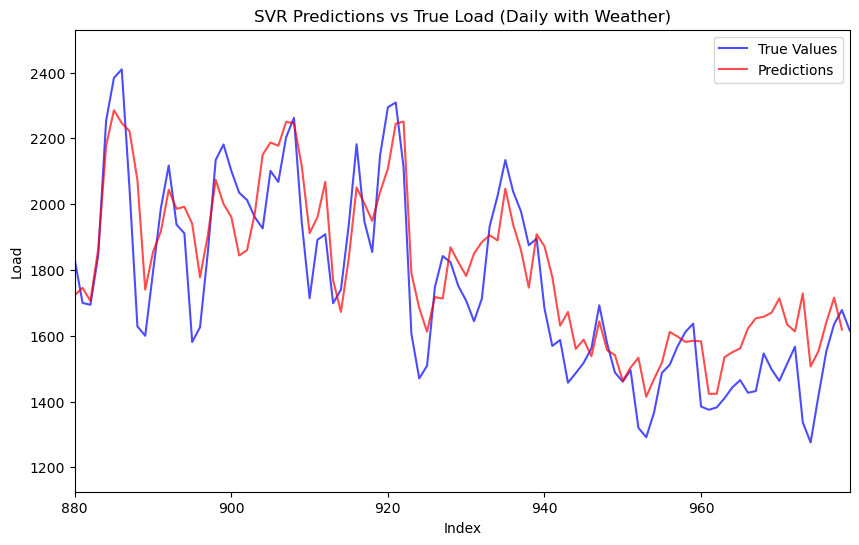

In [17]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 100 

y_true = y_test_inv
y_pred = test_pred
x = np.arange(len(y_true))

window = 100
lag = 1

fig, ax = plt.subplots(figsize=(10,6))
line_true, = ax.plot([], [], label="True Values", color="blue", alpha=0.7)
line_pred, = ax.plot([], [], label="Predictions", color="red", alpha=0.7)
ax.set_ylim(min(y_true.min(), y_pred.min())*0.95, max(y_true.max(), y_pred.max())*1.05)
ax.set_xlabel("Index")
ax.set_ylabel("Load")
ax.set_title("SVR Predictions vs True Load (Daily with Weather)")
ax.legend()

def update(frame):
    start = max(0, frame - window)
    end = frame
    line_true.set_data(x[start:end], y_true[start:end])
    
    pred_start = max(0, frame - window - lag)
    pred_end = max(0, frame - lag)
    line_pred.set_data(x[pred_start:pred_end], y_pred[pred_start:pred_end])
    
    ax.set_xlim(x[start], x[end-1] if end > start else x[start]+1)
    return line_true, line_pred

ani = FuncAnimation(
    fig, update,
    frames=range(0, len(x), 10),
    interval=20, blit=True
)
HTML(ani.to_jshtml())


In [18]:
mape = np.mean(np.abs((y_test_inv - test_pred) / y_test_inv)) * 100
print(f"Testing MAPE: {mape:.2f}%")

eps = 1e-6
mape = np.mean(np.abs((y_train_inv - train_pred) / (y_train_inv + eps))) * 100
print(f"Training MAPE: {mape:.2f}%")

mape = np.mean(np.abs((y_val_inv - val_pred) / y_val_inv)) * 100
print(f"Val MAPE: {mape:.2f}%")


Testing MAPE: 5.53%
Training MAPE: 3.60%
Val MAPE: 5.43%


In [19]:
from sklearn.metrics import r2_score

rmse = np.sqrt(mean_squared_error(y_test_inv, test_pred))
print(f"Testing RMSE: {rmse}")

r2 = r2_score(y_test_inv, test_pred)
print(f"Testing R2: {r2}")

Testing RMSE: 108.98684083387279
Testing R2: 0.7610149924064675


In [20]:
import joblib

joblib.dump(best_model, "svr_daily_with_weather_model.joblib")
print("Model saved as: svr_daily_with_weather_model.joblib")


Model saved as: svr_daily_with_weather_model.joblib


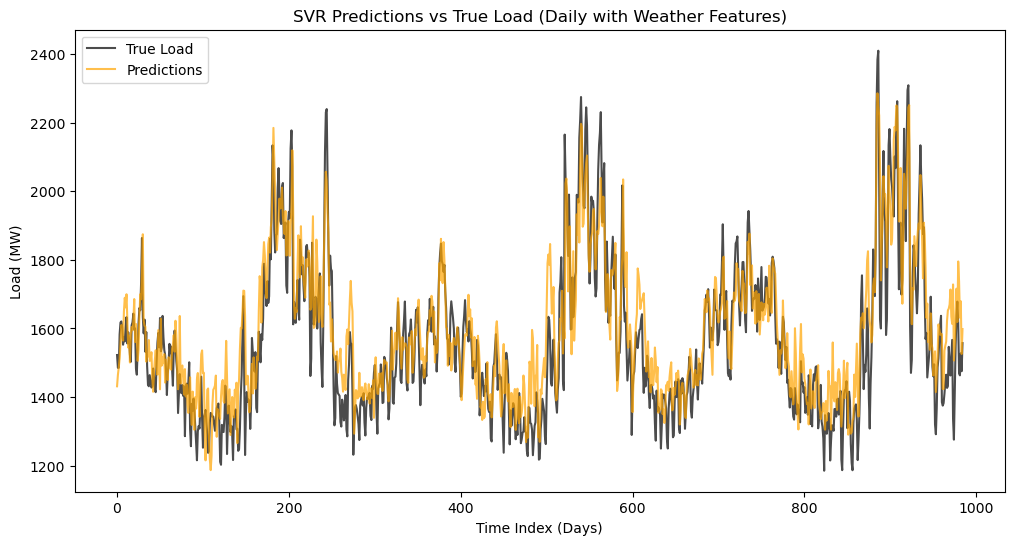

In [21]:
subset_start = 0
subset_end = min(1000, len(y_test_inv))
plt.figure(figsize=(12,6))
plt.plot(y_test_inv[subset_start:subset_end], label="True Load", color="black", alpha=0.7)
plt.plot(test_pred[subset_start:subset_end], label="Predictions", color="orange", alpha=0.7)
plt.xlabel("Time Index (Days)")
plt.ylabel("Load (MW)")
plt.title("SVR Predictions vs True Load (Daily with Weather Features)")
plt.legend()
plt.show()